In [16]:
import numpy as np
import matplotlib.pyplot as plt

import h5py

from scipy.signal import welch

In [47]:
file_0e_noeb = r"E:\lorentz_force\sphere_20250708\20250711_5e-8mbar\20250711_0e_noeb_0.hdf5"
file_0e_b    = r"E:\lorentz_force\sphere_20250708\20250711_5e-8mbar\20250711_0e_b4_7khz_0.hdf5"
file_0e_eb   = r"E:\lorentz_force\sphere_20250708\20250711_5e-8mbar\20250711_0e_b4_7khz_e69khz_0.hdf5"

file_m160e_eb_0_3 = r"E:\lorentz_force\sphere_20250708\20250711_5e-8mbar\20250711_minus160e_b4_7khz_e69khz_0_3vpp_0.hdf5"
file_m160e_eb_0_2 = r"E:\lorentz_force\sphere_20250708\20250711_5e-8mbar\20250711_minus160e_b4_7khz_e69khz_0_2vpp_0.hdf5"
file_m160e_eb_0_15 = r"E:\lorentz_force\sphere_20250708\20250711_5e-8mbar\20250711_minus160e_b4_7khz_e69khz_0_15vpp_0.hdf5"

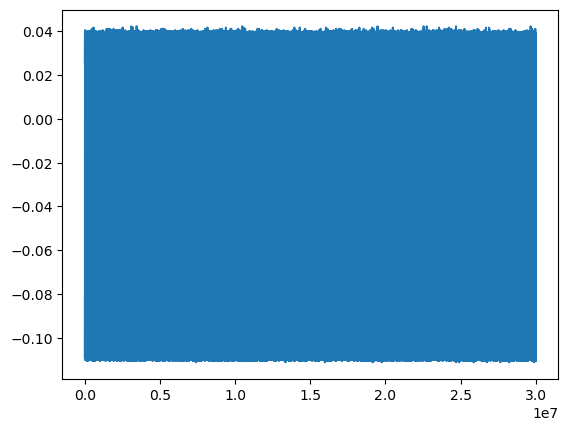

In [48]:
with h5py.File(file_m160e_eb_0_15, 'r') as f:
    plt.plot(f['data']['channel_g'][:] * f['data']['channel_g'].attrs['adc2mv'] / 1000)

In [31]:
def get_disp_timestream(file):
    with h5py.File(file, 'r') as f:
        dt = f['data'].attrs['delta_t']
        # aa = f['data']['channel_a'][:] * f['data']['channel_a'].attrs['adc2mv'] / 1000
        # bb = f['data']['channel_b'][:] * f['data']['channel_b'].attrs['adc2mv'] / 1000
        # cc = f['data']['channel_c'][:] * f['data']['channel_c'].attrs['adc2mv'] / 1000
        dd = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv'] / 1000
        f.close()

    # return dt, aa, bb, cc, dd
    return dt, dd

def get_psd(dt, timestream, nperseg=2**16):
    fs = int(1 / dt)
    ff, pp = welch(timestream, fs, nperseg=nperseg)
    return ff, pp


In [32]:
dt, dd_no_eb = get_disp_timestream(file=file_0e_noeb)
dt, dd_b = get_disp_timestream(file=file_0e_b)
dt, dd_eb = get_disp_timestream(file=file_0e_eb)

In [33]:
ff, pp_noeb = get_psd(dt, dd_no_eb)
ff, pp_b = get_psd(dt, dd_b)
ff, pp_eb = get_psd(dt, dd_eb)

Text(0, 0.5, '$V^2$/Hz')

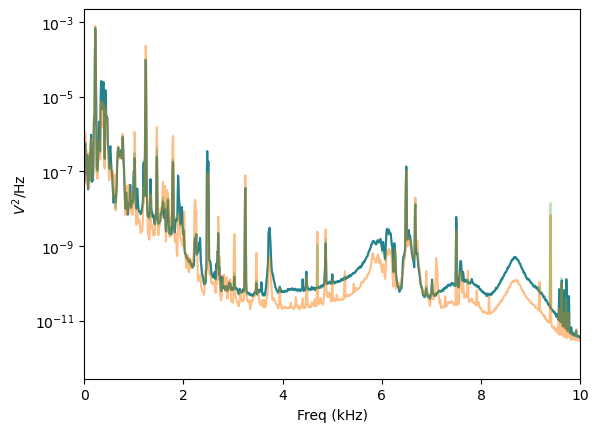

In [41]:
plt.plot(ff/1000, pp_noeb)
plt.plot(ff/1000, pp_b, alpha=0.5)
plt.plot(ff/1000, pp_eb, alpha=0.3)

plt.yscale('log')
plt.xlim(0, 10)

plt.xlabel('Freq (kHz)')
plt.ylabel('$V^2$/Hz')